# **CNN** on Fashion mnist dataset

### Importing the Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Conv2D , MaxPooling2D , Flatten , Dense , Dropout
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


### Loading the dataset

In [ ]:
(X_train , y_train)  , (X_test , y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Visualizing the datasets

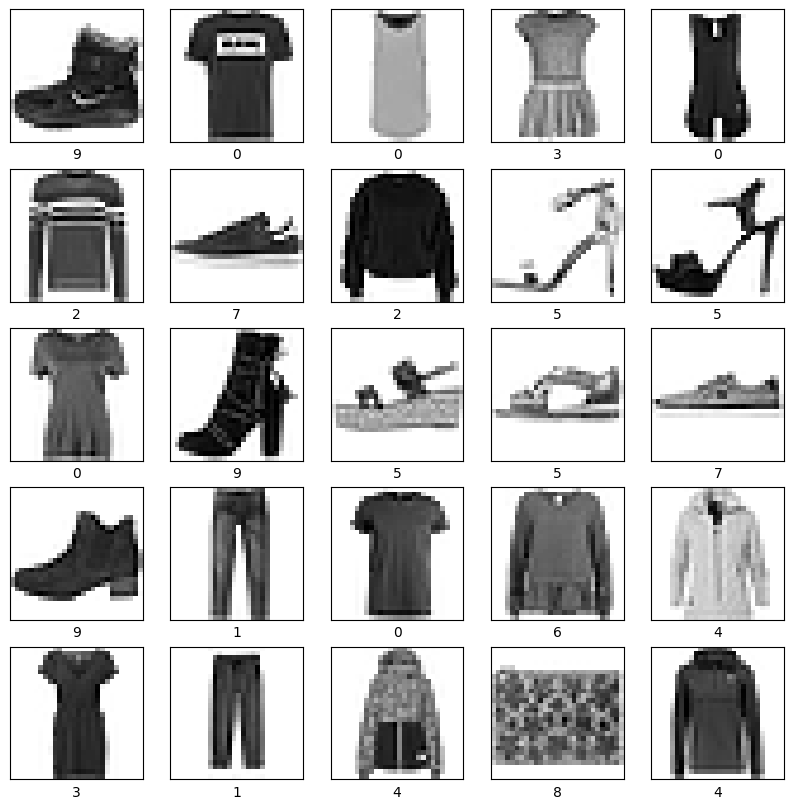

In [ ]:
plt.figure(figsize=(10,10))
for i in range (25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(X_train[i] , cmap = plt.cm.binary )
  plt.xlabel(y_train[i])
plt.show()

In [ ]:
print(f"we have {len(X_train)} images in the training set and {len(X_test)} images in the test set.")
print(f"The size of the images is {X_train[0].shape}")

we have 60000 images in the training set and 10000 images in the test set.
The size of the images is (28, 28)


In [ ]:
X_train.shape , y_train.shape , X_test.shape , y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

# Preprocessing

In [ ]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0


In [ ]:
# also need to change the data type to float32 Data Normalize
print("\n pixel values after normalization: ")
for row in X_train[0]:
  for pixel in row:
    print("{:0.3f}".format(pixel), end="")
    print()


 pixel values after normalization: 
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.004
0.000
0.000
0.051
0.286
0.000
0.000
0.004
0.016
0.000
0.000
0.000
0.000
0.004
0.004
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.012
0.000
0.141
0.533
0.498
0.243
0.212
0.000
0.000
0.000
0.004
0.012
0.016
0.000
0.000
0.012
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.024
0.000
0.400
0.800
0.690
0.525
0.565
0.482
0.0

# Build the model

In [ ]:
input_layer = tf.keras.layers.Input(shape=(28,28,1))
model = tf.keras.Sequential([
    input_layer ,
    layers.Conv2D(filters = 10 , kernel_size = (3,3) , activation='relu') ,
    layers.Conv2D(filters = 10 , kernel_size=(3,3) , activation='relu') ,
    layers.MaxPooling2D(),
    layers.Conv2D(filters = 10 , kernel_size = (3,3) , activation = 'relu') ,
    layers.Conv2D(filters = 10 , kernel_size = (3,3) , activation = 'relu') ,
    layers.MaxPooling2D() ,
    layers.Flatten(),
    layers.Dense(10 , activation = 'softmax')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 10)       │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,440 (17.34 KB)

 Trainable params: 4,440 (17.34 KB)

 Non-trainable params: 0 (0.00 B)

# Compile the model

In [ ]:
model.compile(optimizer = 'adam' , loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

#Evaluating the model

In [ ]:
from keras.callbacks import EarlyStopping

# Define the callback function

early_stopping = EarlyStopping(patience=3)
history = model.fit(X_train , y_train , epochs = 10 , batch_size = 32 , validation_data = (X_test , y_test) ,callbacks=[early_stopping] )

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9038 - loss: 0.2691 - val_accuracy: 0.8851 - val_loss: 0.3066
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9051 - loss: 0.2627 - val_accuracy: 0.8916 - val_loss: 0.2999
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9072 - loss: 0.2586 - val_accuracy: 0.8956 - val_loss: 0.2965
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9085 - loss: 0.2526 - val_accuracy: 0.8949 - val_loss: 0.2913
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9096 - loss: 0.2492 - val_accuracy: 0.8966 - val_loss: 0.2903
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9107 - loss: 0.2463 - val_accuracy: 0.8988 - val_loss: 0.2891
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9122 - loss: 0.2431 - val_accuracy: 0.8970 - val_loss: 0.2931
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9128 - loss: 0.2407 - 

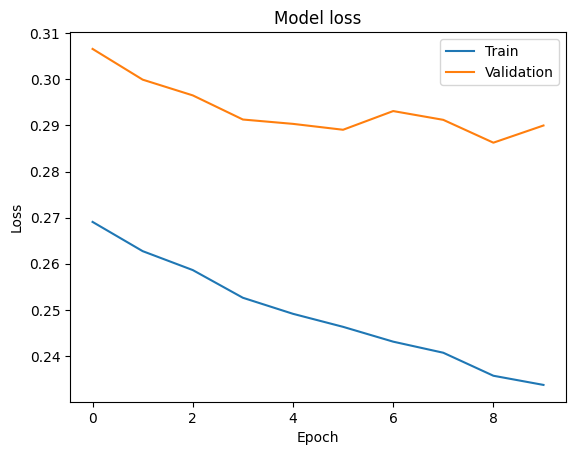

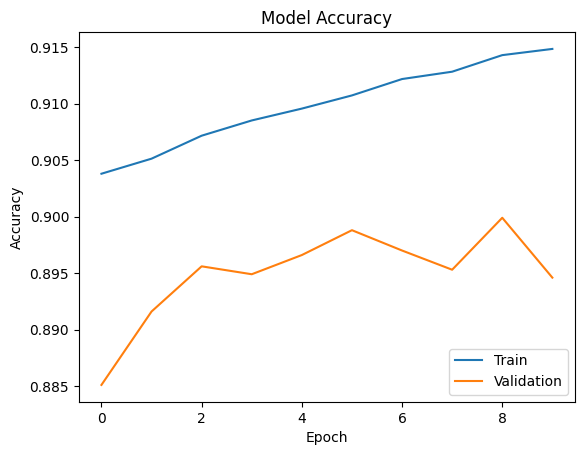

In [ ]:
# Evaluating the model (using Mean Squared Error)
loss = model.evaluate(X_test, y_test, verbose=0)
loss

# Plotting the training and testing loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# plot the accuracy of training and validation

# Plotting the training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

### Test Accuracy and Loss

In [ ]:
print(f"Test Loss: {loss[0]:.4f}")
print(f"Test Accuracy: {loss[1]:.4f}")

Test Loss: 0.2900
Test Accuracy: 0.8946


### Confusion Matrix and Classification Report

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Reshape X_test to include the channel dimension (1 for grayscale)
X_test_reshaped = X_test.reshape(X_test.shape[0], 28, 28, 1)

# Predict probabilities for the test set
y_pred_probabilities = model.predict(X_test_reshaped)
# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Define class names for Fashion MNIST for better readability
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.79      0.90      0.84      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.83      0.89      0.86      1000
       Dress       0.93      0.84      0.88      1000
        Coat       0.80      0.88      0.84      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.75      0.61      0.67      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.95      0.97      0.96      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



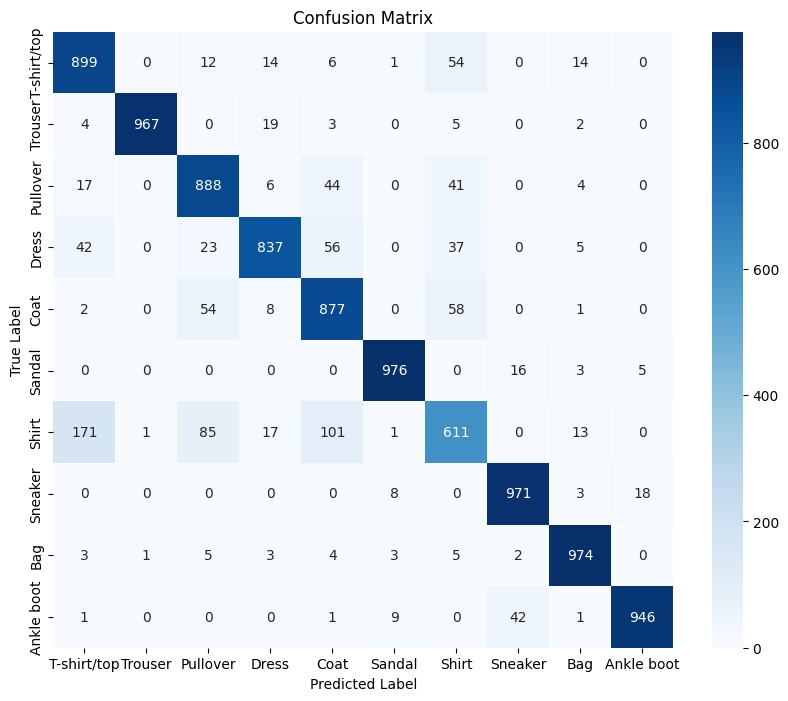

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

(28, 28)
(28, 28, 1)


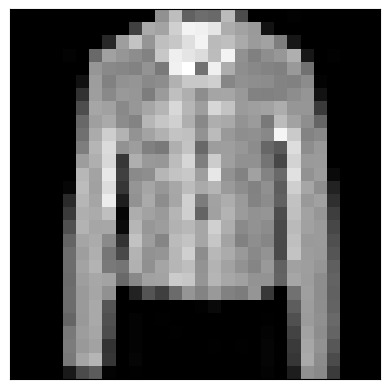

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step
The model predicts that this image is a 4.


In [ ]:
# grab an image
img = X_test[10]
print(img.shape)
# # rehape the image to (28, 28, 1)
img = img.reshape((28, 28, 1))
print(img.shape)
plt.imshow(img, cmap="gray")
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.show()
# predict the image
predictions = model.predict(img.reshape(1, 28, 28, 1))
print(f"The model predicts that this image is a {predictions.argmax()}.")

In [ ]:
# Save the model to be used later
model.save('models_saved/fashion_mnist_cnn.h5')